<a href="https://colab.research.google.com/github/pradp27/DSA0205-Computer-Vision-with-Open-CV/blob/main/CO2_AT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Manual Histogram Equalization on a 4-bit Sample Image Matrix

In [1]:
import numpy as np

img = np.array([
    [0,1,2,3],
    [4,5,6,7],
    [8,9,10,11],
    [12,13,14,15]
])

hist = np.zeros(16)

for i in img.flatten():
    hist[i] += 1

pdf = hist / img.size
cdf = np.cumsum(pdf)
equalized = np.floor(cdf * 15).astype(int)

result = equalized[img]

print("Original Image")
print(img)
print("\nHistogram")
print(hist)
print("\nEqualized Image")
print(result)

Original Image
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

Histogram
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Equalized Image
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


2. Negative and Log Transformations on a Grayscale Image

Saving doraemon.jpg to doraemon.jpg


/tmp/ipykernel_1099/2978561617.py:13: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_1099/2978561617.py:13: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_1099/2978561617.py:14: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + gray)
/tmp/ipykernel_1099/2978561617.py:14: RuntimeWarning: invalid value encountered in multiply
  log_img = c * np.log(1 + gray)
/tmp/ipykernel_1099/2978561617.py:15: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_img, dtype=np.uint8)


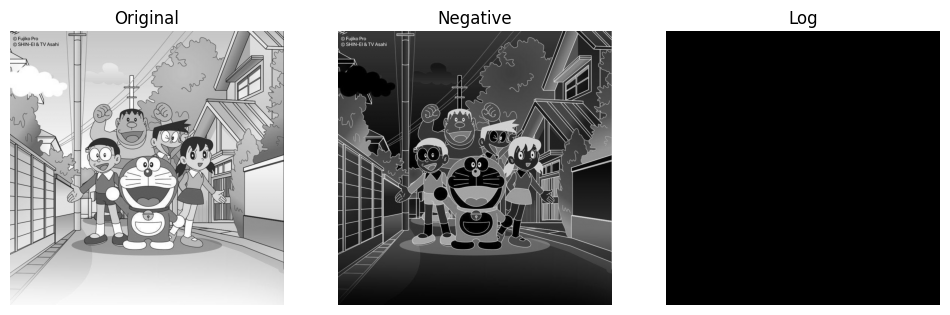

In [2]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

negative = 255 - gray

c = 255 / np.log(1 + np.max(gray))
log_img = c * np.log(1 + gray)
log_img = np.array(log_img, dtype=np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(gray,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(negative,cmap='gray')
plt.title("Negative")
plt.axis("off")

plt.subplot(133)
plt.imshow(log_img,cmap='gray')
plt.title("Log")
plt.axis("off")

plt.show()

3. Power-Law (Gamma) **Transformation**

Saving doraemon.jpg to doraemon (1).jpg


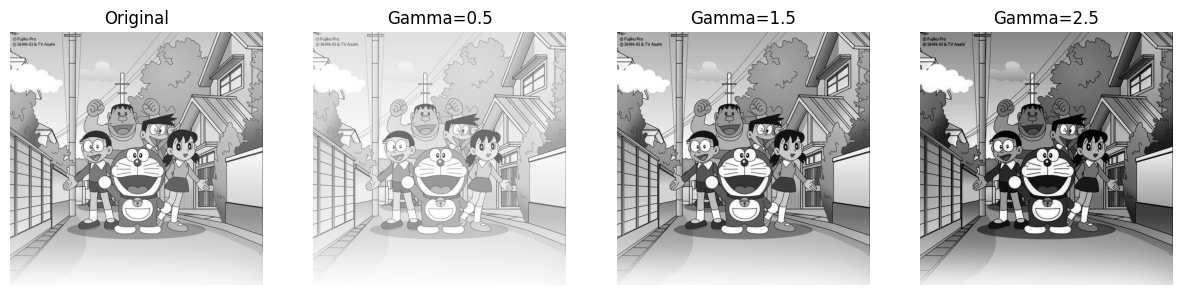

In [3]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

gamma1 = np.array(255*(img/255)**0.5,dtype='uint8')
gamma2 = np.array(255*(img/255)**1.5,dtype='uint8')
gamma3 = np.array(255*(img/255)**2.5,dtype='uint8')

plt.figure(figsize=(15,4))

plt.subplot(141)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(gamma1,cmap='gray')
plt.title("Gamma=0.5")
plt.axis("off")

plt.subplot(143)
plt.imshow(gamma2,cmap='gray')
plt.title("Gamma=1.5")
plt.axis("off")

plt.subplot(144)
plt.imshow(gamma3,cmap='gray')
plt.title("Gamma=2.5")
plt.axis("off")

plt.show()

4. Piecewise Linear Contrast Stretching

Saving doraemon.jpg to doraemon (2).jpg


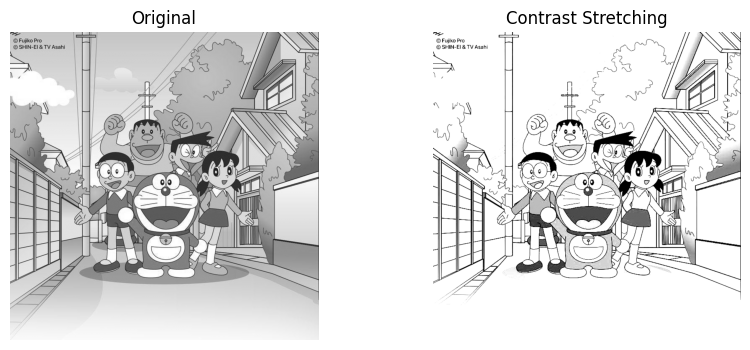

In [4]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

r1,s1 = 70,0
r2,s2 = 140,255

stretch = np.piecewise(
    img,
    [img<=r1,(img>r1)&(img<=r2),img>r2],
    [
        lambda x:(s1/r1)*x,
        lambda x:((s2-s1)/(r2-r1))*(x-r1)+s1,
        lambda x:((255-s2)/(255-r2))*(x-r2)+s2
    ]
)

stretch = np.uint8(stretch)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(stretch,cmap='gray')
plt.title("Contrast Stretching")
plt.axis("off")

plt.show()

5. Mean (Average) Filter

Saving doraemon.jpg to doraemon (3).jpg


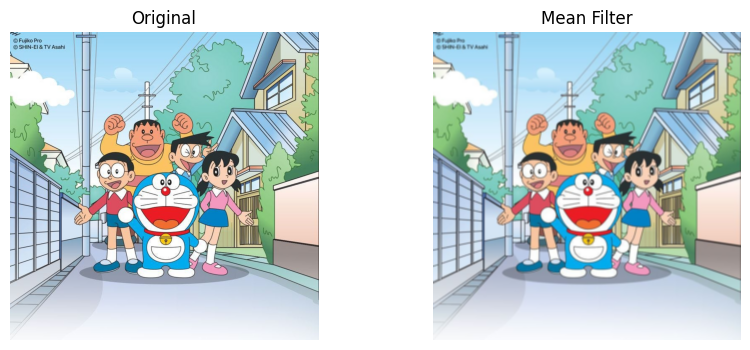

In [5]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)))
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

filtered = cv2.blur(img,(5,5))

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(filtered)
plt.title("Mean Filter")
plt.axis("off")

plt.show()

6. Median Filter for Salt-and-Pepper Noise Removal

Saving doraemon.jpg to doraemon (4).jpg


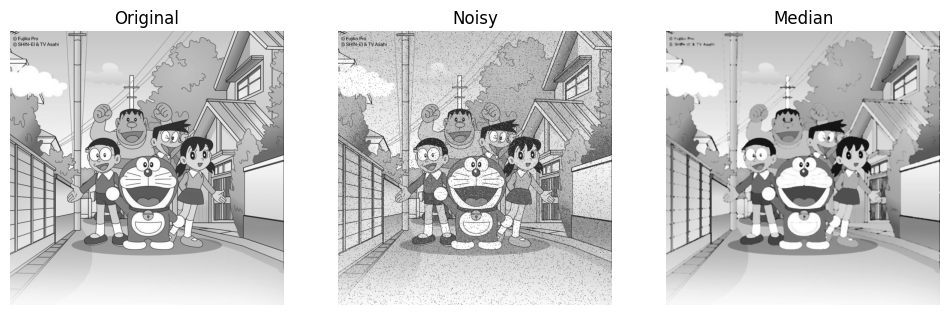

In [6]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

noise = img.copy()

p = 0.05
rand = np.random.rand(*img.shape)

noise[rand < p/2] = 0
noise[rand > 1-p/2] = 255

median = cv2.medianBlur(noise,5)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(noise,cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(133)
plt.imshow(median,cmap='gray')
plt.title("Median")
plt.axis("off")

plt.show()

7. Sharpening Using the Laplacian Operator

Saving doraemon.jpg to doraemon (5).jpg


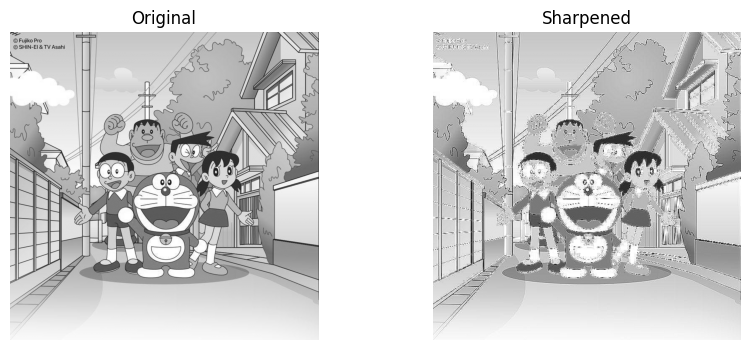

In [7]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

lap = cv2.Laplacian(img,cv2.CV_64F)
sharp = cv2.convertScaleAbs(img-lap)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(sharp,cmap='gray')
plt.title("Sharpened")
plt.axis("off")

plt.show()

8. High-Boost Filtering

Saving doraemon.jpg to doraemon (6).jpg


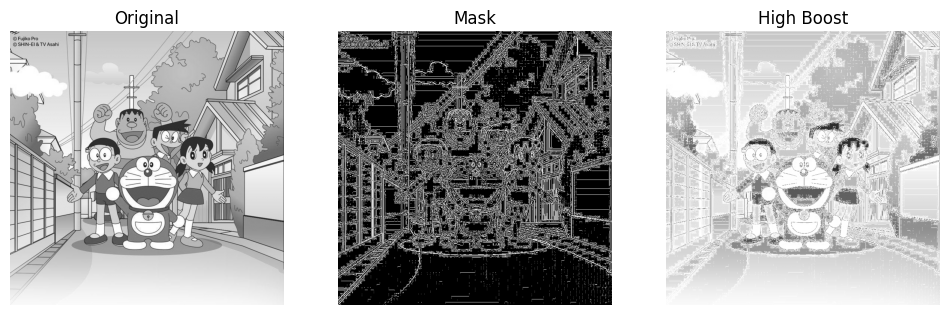

In [8]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

blur = cv2.GaussianBlur(img,(5,5),0)

mask = img-blur

k = 2

boost = cv2.add(img,np.uint8(k*mask))

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask,cmap='gray')
plt.title("Mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(boost,cmap='gray')
plt.title("High Boost")
plt.axis("off")

plt.show()

9. Frequency Domain Low-Pass Filtering

Saving doraemon.jpg to doraemon (7).jpg


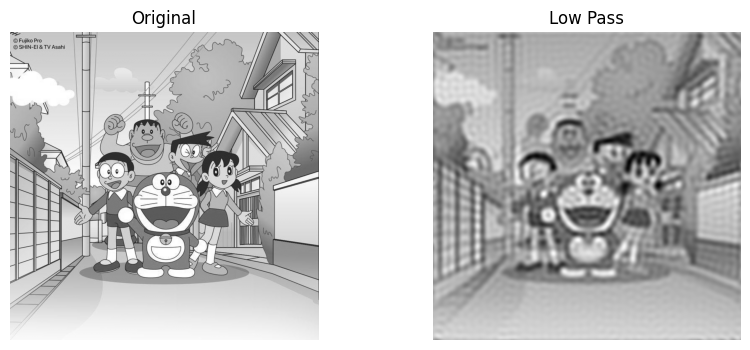

In [9]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

dft = np.fft.fft2(img)
shift = np.fft.fftshift(dft)

rows,cols = img.shape
crow,ccol = rows//2,cols//2

mask = np.zeros((rows,cols),np.uint8)
r = 40

Y,X = np.ogrid[:rows,:cols]
mask[(X-ccol)**2+(Y-crow)**2<=r*r] = 1

filtered = shift*mask

result = np.fft.ifft2(np.fft.ifftshift(filtered))
result = np.abs(result)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap='gray')
plt.title("Low Pass")
plt.axis("off")

plt.show()

10. Frequency Domain High-Pass Filtering

Saving doraemon.jpg to doraemon (8).jpg


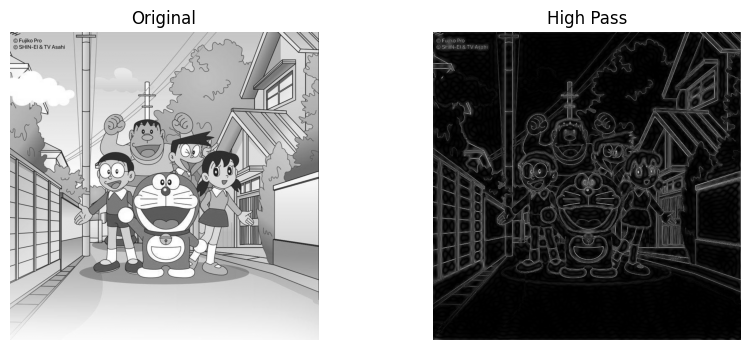

In [10]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

dft = np.fft.fft2(img)
shift = np.fft.fftshift(dft)

rows,cols = img.shape
crow,ccol = rows//2,cols//2

mask = np.ones((rows,cols),np.uint8)
r = 40

Y,X = np.ogrid[:rows,:cols]
mask[(X-ccol)**2+(Y-crow)**2<=r*r] = 0

filtered = shift*mask

result = np.fft.ifft2(np.fft.ifftshift(filtered))
result = np.abs(result)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap='gray')
plt.title("High Pass")
plt.axis("off")

plt.show()

11. Point Detection Using Laplacian Mask

Saving doraemon.jpg to doraemon (9).jpg


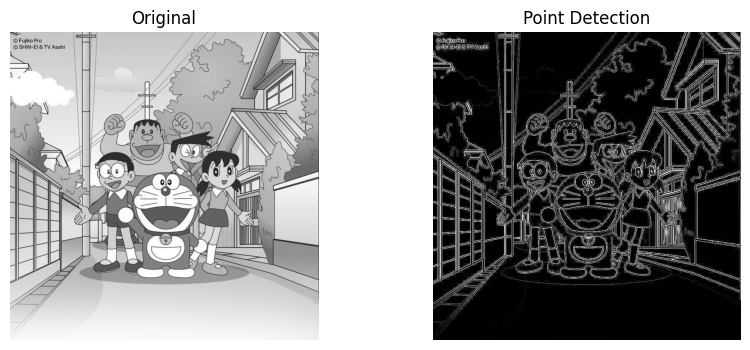

In [11]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

kernel = np.array([[-1,-1,-1],
                   [-1,8,-1],
                   [-1,-1,-1]])

points = cv2.filter2D(img,-1,kernel)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(points,cmap='gray')
plt.title("Point Detection")
plt.axis("off")

plt.show()

12. Line Detection Using Directional Masks

Saving doraemon.jpg to doraemon (10).jpg


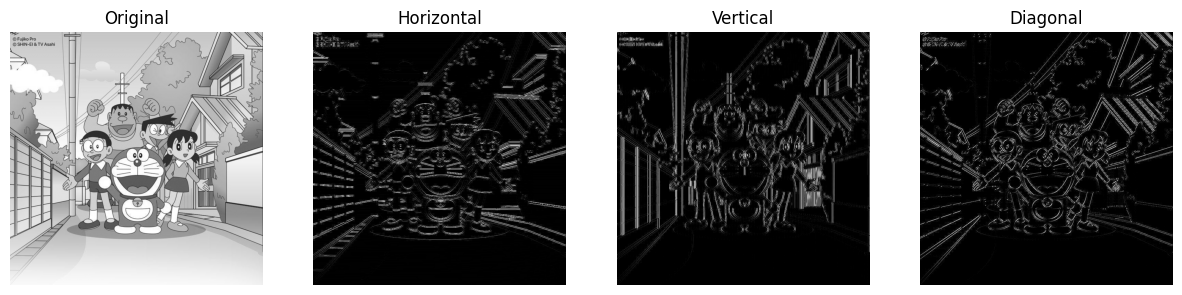

In [12]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

horizontal = np.array([[-1,-1,-1],[2,2,2],[-1,-1,-1]])
vertical = np.array([[-1,2,-1],[-1,2,-1],[-1,2,-1]])
diagonal = np.array([[2,-1,-1],[-1,2,-1],[-1,-1,2]])

h = cv2.filter2D(img,-1,horizontal)
v = cv2.filter2D(img,-1,vertical)
d = cv2.filter2D(img,-1,diagonal)

plt.figure(figsize=(15,4))

plt.subplot(141)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(h,cmap='gray')
plt.title("Horizontal")
plt.axis("off")

plt.subplot(143)
plt.imshow(v,cmap='gray')
plt.title("Vertical")
plt.axis("off")

plt.subplot(144)
plt.imshow(d,cmap='gray')
plt.title("Diagonal")
plt.axis("off")

plt.show()

13. Global Thresholding Using Otsu's Method

Saving doraemon.jpg to doraemon (11).jpg
Threshold = 156.0


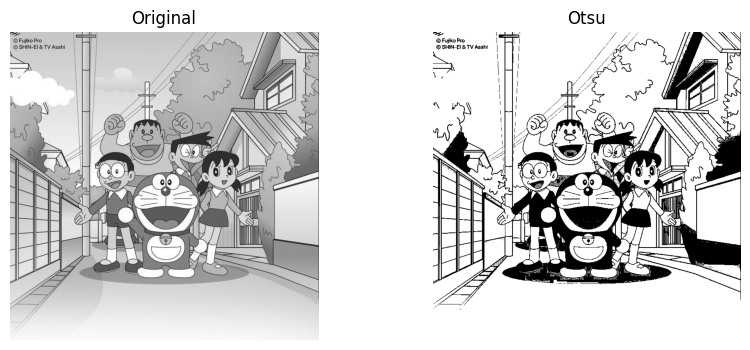

In [13]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

t,th = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print("Threshold =",t)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(th,cmap='gray')
plt.title("Otsu")
plt.axis("off")

plt.show()

14. Region Growing Segmentation

Saving doraemon.jpg to doraemon (12).jpg


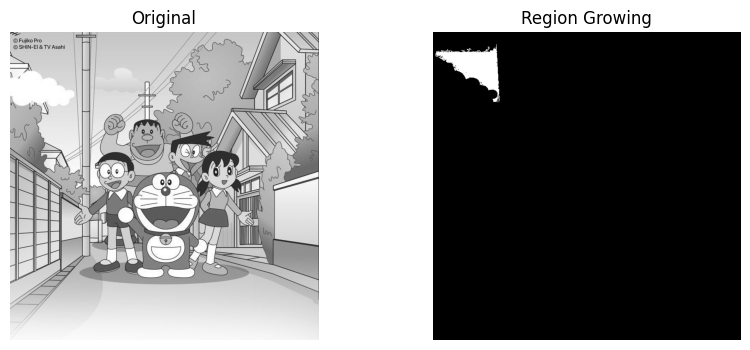

In [14]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img = cv2.imread(next(iter(uploaded)),0)

seed = (100,100)
threshold = 10

visited = np.zeros_like(img,dtype=bool)
result = np.zeros_like(img)

stack = [seed]

while stack:
    x,y = stack.pop()
    if x<0 or y<0 or x>=img.shape[0] or y>=img.shape[1]:
        continue
    if visited[x,y]:
        continue
    visited[x,y] = True
    if abs(int(img[x,y])-int(img[seed])) < threshold:
        result[x,y] = 255
        stack.extend([(x+1,y),(x-1,y),(x,y+1),(x,y-1)])

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap='gray')
plt.title("Region Growing")
plt.axis("off")

plt.show()

15. Edge Linking Using Hough Transform

Saving doraemon.jpg to doraemon (15).jpg


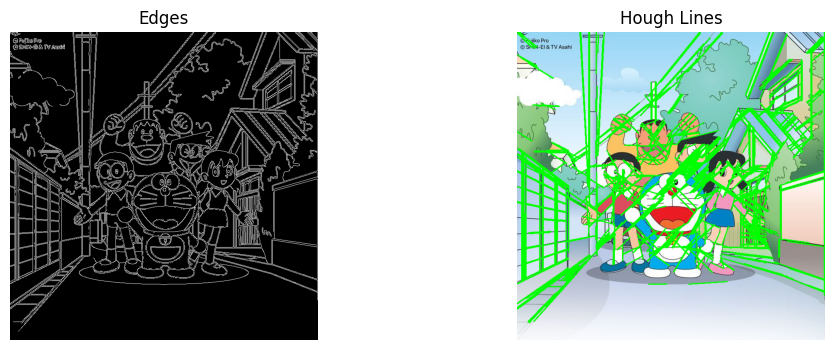

In [18]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, 80, minLineLength=30, maxLineGap=10)

if lines is not None:
    lines = lines.reshape(-1, 4)
    for x1, y1, x2, y2 in lines:
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(12,4))

plt.subplot(121)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Hough Lines")
plt.axis("off")

plt.show()